### EX1
Considerăm o urnă în care avem 3 bile roşii, 4 albastre şi 2 negre. Aruncăm un zar; dacă obţinem un număr prim,
adăugăm o bilă neagră în urnă, dacă obţinem 6, adăugăm o bilă roşie, iar în celelalte cazuri adăugăm o bilă albastră.
Apoi extragem o bilă din urnă.

a) Simulaţi în Python experimentul de mai sus.

In [ ]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt


def run() :
  r = 3
  a = 4
  n = 2
  dice = np.random.randint(1, 7)
  if dice in [2, 3, 5]:
    n += 1
  elif dice == 6:
    r += 1
  else:
    a += 1

  ball = np.random.randint(1, r + a + n + 1)

  if ball <= r:
    return "Rosu"
  elif ball <= r + a:
    return "Albastru"
  else:
    return "Negru"

b) Folosind modelarea făcută, estimaţi probabilitatea de a obţine o bilă roşie.

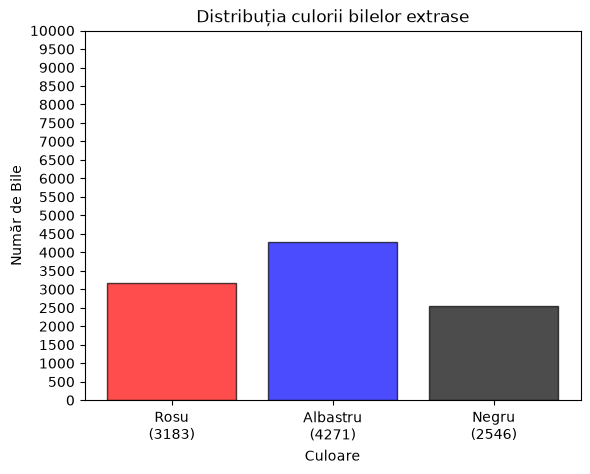

In [150]:


def runs(iter_cnt):
  observed_runs = [run() for i in range(iter_cnt)]
  colors = ["Rosu", "Albastru", "Negru"]
  counts = [observed_runs.count(c) for c in colors]
  plt.bar(colors, counts, alpha=0.7, color=['red', 'blue', 'black'], edgecolor='black')
  plt.title('Distribuția culorii bilelor extrase')
  plt.yticks(np.arange(0, iter_cnt + 1, iter_cnt // 20))
  plt.xticks(range(len(colors)), [f"{c}\n({n})" for c, n in zip(colors, counts)])

  plt.xlabel('Culoare')
  plt.ylabel('Număr de Bile')
  plt.show()


runs(10000)

Estimez:
  Rosu     -> 32.5% 
  Albastru -> 42.5% 
  Negru    -> 25%
  (aproximări grosolane)

c) Calculaţi probabilitatea teoretică a evenimentului de mai sus şi comparaţi-o cu cea obţinută.

### Definim următoarele evenimente:
  - P -> Se obține un număr **prim** în urma aruncării cu zarul
  - S -> Se obține un număr **6** în urma aruncării cu zarul
  - O -> Se obține **1 sau 4** în urma aruncării cu zarul
  - R -> Se extrage o bilă <span style="color:red">roșie</span>.
  - A -> Se extrage o bilă <span style="color:blue"> albastră</span>.
  - N -> Se extrage o bilă <span style="color:black">neagră</span>.

  $$
  \begin{aligned}
  P(R) &= P(R|P) + P(R|S) + P(R|O) = \\
       &= P(R \cap P) \cdot P(P) + \\
       &  P(R \cap S) \cdot P(S) + \\
       &  P(R \cap O) \cdot P(O) \\
       &= \frac{3}{10} \cdot \frac{1}{2} + \frac{4}{10} \cdot \frac{1}{6} + \frac{3}{10} \cdot \frac{1}{3} \\
       &= \frac{19}{60} \\
       &= 31.(6)%  
  \end{aligned}
  $$   
  Rosu     -> 31.(6)% 
  Albastru -> 43.(3)% 
  Negru    -> 25%

In [ ]:
with pm.Model() as model:

    
    